# IT Service Customer Purchase Prediction

##Data Loading & Understanding

#### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

####Load Dataset

In [ ]:
df = pd.read_csv('customer_data.csv')


In [ ]:
df.head()

,Customer_ID,Age,Gender,City,Company_Size,Industry,Annual_Revenue,Employees,Current_IT_Budget,Years_As_Customer,...,Emails_Opened,Support_Tickets,Uses_Cloud,Uses_Cybersecurity,Uses_Data_Analytics,Uses_AI,Previous_Purchases,Lead_Source,Discount_Offered,Purchased
0,CUST_00001,60,Male,Mumbai,Medium,Logistics,36.877561,166,2.797471,2,...,5,5,0,0,1,0,4,Email Campaign,0,1
1,CUST_00002,50,Male,Vadodara,Medium,IT,66.085446,380,6.899638,10,...,6,1,1,0,1,0,1,Referral,10,1
2,CUST_00003,36,Female,Chennai,Medium,Manufacturing,57.846954,291,3.949801,7,...,6,3,1,0,1,0,1,Referral,0,1
3,CUST_00004,29,Female,Delhi,Small,Healthcare,5.358856,44,0.408661,4,...,8,3,1,0,0,0,0,Email Campaign,10,0
4,CUST_00005,42,Female,Delhi,Large,Manufacturing,428.716434,1717,62.575087,0,...,7,0,0,0,0,0,1,Email Campaign,15,0


####Data Understanding

In [ ]:
print("Shape",df.shape)

Shape (5000, 23)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          5000 non-null   object 
 1   Age                  5000 non-null   int64  
 2   Gender               5000 non-null   object 
 3   City                 5000 non-null   object 
 4   Company_Size         5000 non-null   object 
 5   Industry             5000 non-null   object 
 6   Annual_Revenue       5000 non-null   float64
 7   Employees            5000 non-null   int64  
 8   Current_IT_Budget    5000 non-null   float64
 9   Years_As_Customer    5000 non-null   int64  
 10  Website_Visits       5000 non-null   int64  
 11  Demo_Attended        5000 non-null   int64  
 12  Sales_Calls          5000 non-null   int64  
 13  Emails_Opened        5000 non-null   int64  
 14  Support_Tickets      5000 non-null   int64  
 15  Uses_Cloud           5000 non-null   i

In [ ]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'City', 'Company_Size', 'Industry',
       'Annual_Revenue', 'Employees', 'Current_IT_Budget', 'Years_As_Customer',
       'Website_Visits', 'Demo_Attended', 'Sales_Calls', 'Emails_Opened',
       'Support_Tickets', 'Uses_Cloud', 'Uses_Cybersecurity',
       'Uses_Data_Analytics', 'Uses_AI', 'Previous_Purchases', 'Lead_Source',
       'Discount_Offered', 'Purchased'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
City,0
Company_Size,0
Industry,0
Annual_Revenue,0
Employees,0
Current_IT_Budget,0
Years_As_Customer,0


####Statistical Summary

In [ ]:
df.describe()

,Age,Annual_Revenue,Employees,Current_IT_Budget,Years_As_Customer,Website_Visits,Demo_Attended,Sales_Calls,Emails_Opened,Support_Tickets,Uses_Cloud,Uses_Cybersecurity,Uses_Data_Analytics,Uses_AI,Previous_Purchases,Discount_Offered,Purchased
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,41.194600,101.423395,680.451400,9.219429,4.994400,8.00440,0.348800,2.991600,5.010200,2.027000,0.55160,0.395400,0.351200,0.194600,1.532400,7.81500,0.591600
std,11.210025,193.557816,1188.971783,19.492323,3.132783,2.79899,0.476638,1.722476,2.240424,1.427403,0.49738,0.488985,0.477393,0.395932,1.221822,5.99149,0.491587
min,22.000000,0.591830,10.000000,0.024484,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,32.000000,7.878008,62.000000,0.645110,2.000000,6.00000,0.000000,2.000000,3.000000,1.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000
50%,41.000000,21.109068,169.000000,1.806542,5.000000,8.00000,0.000000,3.000000,5.000000,2.000000,1.00000,0.000000,0.000000,0.000000,1.000000,10.00000,1.000000
75%,51.000000,73.567460,445.000000,6.482138,8.000000,10.00000,1.000000,4.000000,6.000000,3.000000,1.00000,1.000000,1.000000,0.000000,2.000000,10.00000,1.000000
max,60.000000,1214.362597,4997.000000,161.064252,10.000000,19.00000,1.000000,14.000000,14.000000,9.000000,1.00000,1.000000,1.000000,1.000000,7.000000,20.00000,1.000000


##Data Preprocessing & Feature Engineering

####Data Quality Check

In [ ]:
print("Null Value: ",df.isnull().sum())
print("Duplicate Values: ",df.duplicated().sum())

Null Value:  Customer_ID            0
Age                    0
Gender                 0
City                   0
Company_Size           0
Industry               0
Annual_Revenue         0
Employees              0
Current_IT_Budget      0
Years_As_Customer      0
Website_Visits         0
Demo_Attended          0
Sales_Calls            0
Emails_Opened          0
Support_Tickets        0
Uses_Cloud             0
Uses_Cybersecurity     0
Uses_Data_Analytics    0
Uses_AI                0
Previous_Purchases     0
Lead_Source            0
Discount_Offered       0
Purchased              0
dtype: int64
Duplicate Values:  0


####Feature Selection

In [ ]:
Y = df['Purchased']

X = df.drop(columns=['Customer_ID','Purchased'])

print("Features: ",X.shape)
print("Target: ",Y.shape)

Features:  (5000, 21)
Target:  (5000,)


####Feature Types

In [ ]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features: ",numerical_features)
print("Categorical Features: ",categorical_features)

Numerical Features:  ['Age', 'Annual_Revenue', 'Employees', 'Current_IT_Budget', 'Years_As_Customer', 'Website_Visits', 'Demo_Attended', 'Sales_Calls', 'Emails_Opened', 'Support_Tickets', 'Uses_Cloud', 'Uses_Cybersecurity', 'Uses_Data_Analytics', 'Uses_AI', 'Previous_Purchases', 'Discount_Offered']
Categorical Features:  ['Gender', 'City', 'Company_Size', 'Industry', 'Lead_Source']


####Preprocessing Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

####Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )
print("X_train: ",X_train.shape)
print("X_test: ",X_test.shape)
print("Y_train: ",Y_train.shape)
print("Y_test: ",Y_test.shape)

X_train:  (4000, 21)
X_test:  (1000, 21)
Y_train:  (4000,)
Y_test:  (1000,)


##Machine Learning Model Building

####Logistic Regression

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, Y_train)
print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


####Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

decision_tree_model.fit(X_train, Y_train)
print("Decision Tree Model Trained Successfully.")

Decision Tree Model Trained Successfully.


####Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

random_forest_model.fit(X_train, Y_train)
print("Random Forest Model Trained Successfully.")

Random Forest Model Trained Successfully.


##Model Evaluation & Selection

#### Accuracy

In [ ]:
from sklearn import model_selection
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': logistic_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model
}

for name, model in models.items():
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    accuracy = accuracy_score(Y_test, Y_pred)
    print(f"{name} Accuracy: {accuracy}")

Logistic Regression Accuracy: 0.679
Decision Tree Accuracy: 0.572
Random Forest Accuracy: 0.676


####Precision

In [ ]:
from sklearn.metrics import precision_score

for name, model in models.items():
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    precision = precision_score(Y_test, Y_pred)
    print(f"{name} Precision: {precision}")

Logistic Regression Precision: 0.7082066869300911
Decision Tree Precision: 0.6462346760070052
Random Forest Precision: 0.6960926193921853


####Recall

In [ ]:
from sklearn.metrics import recall_score

for name, model in models.items():
    Y_pred = model.predict(X_test)
    recall = recall_score(Y_test, Y_pred)
    print(f"{name} Recall: {recall}")

Logistic Regression Recall: 0.7831932773109244
Decision Tree Recall: 0.6201680672268908
Random Forest Recall: 0.8084033613445378


####F1 Score

In [ ]:
from sklearn.metrics import f1_score

for name, model in models.items():
    Y_pred = model.predict(X_test)
    f1 = f1_score(Y_test, Y_pred)
    print(f"{name} F1 Score: {f1}")

Logistic Regression F1 Score: 0.7438148443735035
Decision Tree F1 Score: 0.6329331046312179
Random Forest F1 Score: 0.7480559875583204


####Confusion Matrix

Logistic Regression Confusion Matrix:


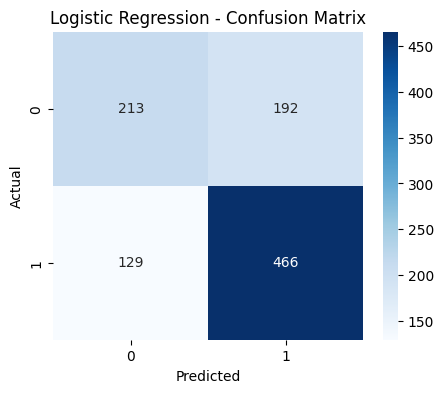

Decision Tree Confusion Matrix:


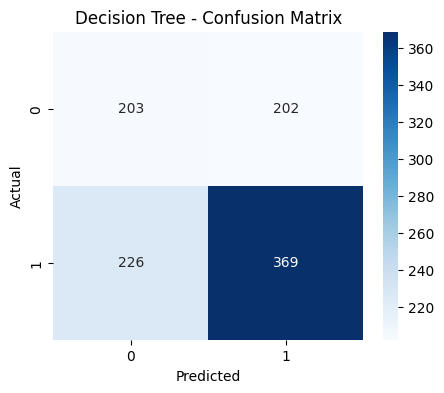

Random Forest Confusion Matrix:


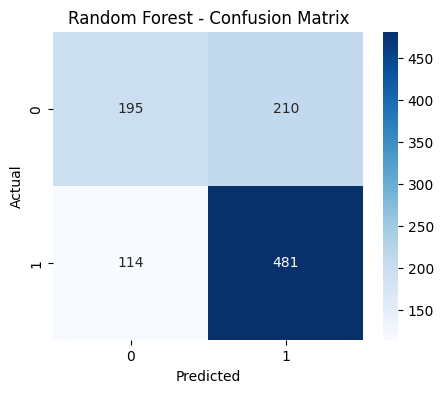

In [ ]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    Y_pred = model.predict(X_test)
    cm = confusion_matrix(Y_test, Y_pred)
    print(f"{name} Confusion Matrix:")

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

####Model Comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(Y_test, y_pred),
        'Precision': precision_score(Y_test, y_pred),
        'Recall': recall_score(Y_test, y_pred),
        'F1 Score': f1_score(Y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.679,0.708207,0.783193,0.743815
1,Decision Tree,0.572,0.646235,0.620168,0.632933
2,Random Forest,0.676,0.696093,0.808403,0.748056


##Service Recommendation

####Customer Segmentation

In [ ]:
def customer_segment(row):
    if row['Uses_AI'] == 'No' and row['Uses_Data_Analytics'] == 'No':
        return 'Traditional'
    elif row['Uses_AI'] == 'Yes':
        return 'AI User'
    elif row['Uses_Data_Analytics'] == 'Yes':
        return 'Data Analytics User'
    elif row['Uses_Cloud'] == 'Yes':
        return 'Cloud User'
    else:
        return 'Other'

df['Customer_Segment'] = df.apply(customer_segment, axis=1)

df[['Customer_ID', 'Customer_Segment']].head()

,Customer_ID,Customer_Segment
0,CUST_00001,Other
1,CUST_00002,Other
2,CUST_00003,Other
3,CUST_00004,Other
4,CUST_00005,Other


####Recommended IT Service

In [ ]:
def recommend_service(row):
    if row['Uses_Cybersecurity'] == 0:
        return 'Cybersecurity'
    elif row['Uses_Cloud'] == 0:
        return 'Cloud Services'
    elif row['Uses_Data_Analytics'] == 0:
        return 'Data Analytics'
    elif row['Uses_AI'] == 0:
        return 'AI Solutions'
    else:
        return 'Advanced IT Solutions'

df['Recommended_Service'] = df.apply(recommend_service, axis=1)

df[['Customer_ID', 'Recommended_Service']].head(20)

,Customer_ID,Recommended_Service
0,CUST_00001,Cybersecurity
1,CUST_00002,Cybersecurity
2,CUST_00003,Cybersecurity
3,CUST_00004,Cybersecurity
4,CUST_00005,Cybersecurity
5,CUST_00006,Cybersecurity
6,CUST_00007,Cybersecurity
7,CUST_00008,Cybersecurity
8,CUST_00009,Cybersecurity
9,CUST_00010,Data Analytics


####Recommendation Logic

In [ ]:

df['Purchase_Prediction'] = random_forest_model.predict(X)
df[['Customer_ID', 'Purchase_Prediction']].head()

,Customer_ID,Purchase_Prediction
0,CUST_00001,1
1,CUST_00002,1
2,CUST_00003,1
3,CUST_00004,0
4,CUST_00005,0


In [ ]:
df['Purchase_Prediction'] = random_forest_model.predict(X)

df[['Customer_ID', 'Purchase_Prediction']].head()

,Customer_ID,Purchase_Prediction
0,CUST_00001,1
1,CUST_00002,1
2,CUST_00003,1
3,CUST_00004,0
4,CUST_00005,0


In [ ]:
df['Final_Recommendation'] = np.where(
    df['Purchase_Prediction'] == 1,
    df['Recommended_Service'],
    'No Offer'
)

df[['Customer_ID', 'Purchase_Prediction', 'Recommended_Service', 'Final_Recommendation']].head()

,Customer_ID,Purchase_Prediction,Recommended_Service,Final_Recommendation
0,CUST_00001,1,Cybersecurity,Cybersecurity
1,CUST_00002,1,Cybersecurity,Cybersecurity
2,CUST_00003,1,Cybersecurity,Cybersecurity
3,CUST_00004,0,Cybersecurity,No Offer
4,CUST_00005,0,Cybersecurity,No Offer


##Power BI Dashboard

####Export Final Dataset for Power BI

In [ ]:
df.to_csv('/content/IT_Service_Final_Data.csv', index=False)

print("File exported successfully!")

File exported successfully!


##Final Business Insights


#### Key Business Findings


1. The dataset contains 5,000 customers, of which 2,958 customers have purchased the service, giving an overall purchase rate of 59.16%.



2. The machine learning model identifies 3,054 customers as predicted buyers, providing a potential customer pool for targeted sales activities.

3. Website leads contribute the largest share of predicted buyers, with 926 customers (30.32%), followed by Referrals with 770 (25.21%) and Email Campaigns with 619 (20.27%). LinkedIn and Cold Calls contribute smaller shares of predicted buyers.

4. Cybersecurity is the most frequently recommended service, accounting for 60.46% of the recommended-service distribution. Cloud Services account for 18.34%, while Data Analytics represents 13.72% and AI Solutions 6.04%.

5. Among predicted buyers, Cybersecurity has the largest recommendation volume, at approximately 1.7K customers, followed by Cloud Services and Data Analytics at approximately 0.5K each.

6. The customer table demonstrates how the model can support individualized sales recommendations. For example, predicted buyers are assigned services such as Cybersecurity, AI Solutions, and Cloud Services, while customers predicted not to purchase are marked “No Offer.”